# Deep Learning Practical Lab
## Keras Representation → Architecture Comparison → Model Optimization

### Goal
You will:
1. Learn how a neural network is represented in TensorFlow/Keras.
2. Choose **one classification dataset** and build shallow, medium, and deep networks on the same data.
3. Compare their learning curves and generalization.
4. Select one model and improve it using optimization / regularization techniques.
5. Build a final optimized model and justify your decisions with evidence.

> **Fair comparison rule:** Keep the dataset split and preprocessing fixed across experiments.

# Part 1 — Neural Networks in TensorFlow/Keras

TensorFlow provides the deep-learning engine. Keras is the high-level API used to define and train models.

The standard workflow is:

**Define → Compile → Fit → Evaluate → Predict**

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1.1 Define the Architecture

Example:

```python
model = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
```

How to read it:

- `Input(shape=(10,))` → 10 input features
- `Dense(64)` → hidden layer with 64 neurons
- `Dense(32)` → second hidden layer with 32 neurons
- `Dense(1, sigmoid)` → binary-classification output

Inside each Dense neuron:

\[
z = w^T x + b
\]

then:

\[
a = g(z)
\]

### Vocabulary

| Concept | Meaning |
|---|---|
| Depth | Number of hidden layers |
| Width | Number of neurons in a layer |
| Parameters | Weights and biases learned from data |
| Hyperparameters | Learning rate, batch size, layers, neurons, dropout, etc. |

## 1.2 Output Layer and Loss

### Binary Classification
```python
layers.Dense(1, activation="sigmoid")
loss="binary_crossentropy"
```

### Multiclass Classification
```python
layers.Dense(n_classes, activation="softmax")
loss="sparse_categorical_crossentropy"
```

Use the multiclass option when the target contains integer class labels such as `0, 1, 2, ...`.

## 1.3 Compile

```python
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
```

- **Loss** → what the model minimizes
- **Optimizer** → how gradients are used to update weights
- **Learning rate** → size of each update
- **Metric** → how we monitor performance

## 1.4 Fit

```python
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)
```

During training:

**Forward Pass → Loss → Backpropagation → Gradients → Weight Update**

`history.history` stores training and validation loss/accuracy across epochs.

## 1.5 Evaluate and Inspect

```python
model.summary()
model.count_params()

model.evaluate(X_test, y_test)
model.predict(X_new)
```

`summary()` shows the architecture and parameter count.  
`evaluate()` is used for final performance on unseen test data.

# Part 2 — Task A: Choose and Prepare One Dataset

Choose **one classification dataset** and use it for the entire lab.

You may use Kaggle, UCI, Scikit-learn, or another instructor-approved public dataset.

### Required dataset description
Write:

1. Dataset name
2. What one row represents
3. Target variable
4. Binary or multiclass
5. Number of rows
6. Number of input features
7. Class distribution
8. Required preprocessing

In [2]:
# TODO: Load your dataset.
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["TARGET"] = data.target

# Examples:
# df = pd.read_csv("data.csv")
# display(df.head())

In [3]:
# TODO: Inspect the dataset.

print(df.shape)
display(df.head())
print(df.dtypes)
print(df.isna().sum())
print(df.duplicated().sum())
print(df["TARGET"].value_counts())
print(df["TARGET"].value_counts(normalize=True))

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,TARGET
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

### Dataset Description

1. **Dataset name:** Breast Cancer Wisconsin (Diagnostic), loaded from `sklearn.datasets.load_breast_cancer`.
2. **What one row represents:** one fine-needle-aspirate sample of a breast mass, summarised by 30 measurements of the cell nuclei in the image - the mean, the standard error, and the worst value of 10 base measurements.
3. **Target variable:** `TARGET`, the diagnosis, where 1 = benign and 0 = malignant.
4. **Binary or multiclass:** binary.
5. **Number of rows:** 569.
6. **Number of input features:** 30.
7. **Class distribution:** 357 benign (62.7%) and 212 malignant (37.3%), mildly imbalanced, so every split is stratified on the target.
8. **Required preprocessing:** there are no missing values and no duplicate rows, and all 30 features are already `float64`, so no imputation, encoding, or type correction is needed. The features sit on very different scales (`mean area` in the hundreds against `mean smoothness` around 0.1), so `StandardScaler` is fitted on the training split only and then applied to the validation and test splits. The stratified 70/15/15 split gives 398 training, 85 validation, and 86 test rows.

In [4]:
# TODO: Define input features X and target y.

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

# Example:
# X = df.drop(columns=["TARGET"])
# y = df["TARGET"]

## Preprocessing Rules

Perform the preprocessing required by your data:

- Handle missing values
- Encode categorical features
- Correct data types
- Scale numerical features when appropriate

> **Avoid data leakage:** fit preprocessing objects such as `StandardScaler` on training data only.

In [5]:
# TODO: Create fixed Train / Validation / Test splits.
# Suggested: 70% / 15% / 15%
#
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=SEED, stratify=y_temp
)

In [6]:
# TODO: Scale features if appropriate.
#
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# TODO: Determine output configuration after preparing y_train.
#
input_dim = X_train.shape[1]
n_classes = len(np.unique(y_train))

if n_classes == 2:
    output_units = 1
    output_activation = "sigmoid"
    loss_function = "binary_crossentropy"
else:
    output_units = n_classes
    output_activation = "softmax"
    loss_function = "sparse_categorical_crossentropy"

print("Input features:", input_dim)
print("Classes:", n_classes)
print("Output activation:", output_activation)
print("Loss function:", loss_function)

Input features: 30
Classes: 2
Output activation: sigmoid
Loss function: binary_crossentropy


# Part 3 — Learning-Curve Helper

Use the same plotting function for every experiment.

In [8]:
def plot_learning_curves(history, title):
    h = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    if "accuracy" in h:
        plt.figure(figsize=(7, 4))
        plt.plot(h["accuracy"], label="Train Accuracy")
        plt.plot(h["val_accuracy"], label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(title + " — Accuracy")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

# Part 4 — Task B: Compare Network Depth

Build **three models** using the same dataset:

### M1 — Shallow
**1 hidden layer**

### M2 — Medium
**3 hidden layers**

### M3 — Deep
**5 or more hidden layers**

For this stage, keep the following fixed:

- Dataset split
- Preprocessing
- Optimizer
- Learning rate
- Batch size
- Maximum epochs

Do **not** use Dropout or BatchNorm yet.

The main variable being tested is **network architecture / depth**.

## Architecture Plan

Complete before training:

| Model | Hidden Layers | Neurons per Layer | Activation | Parameters |
|---|---:|---|---|---:|
| Shallow | 1 | 32 | ReLU | 1,025 |
| Medium | 3 | 64, 32, 16 | ReLU | 4,609 |
| Deep | 5 | 256, 128, 64, 32, 16 | ReLU | 51,713 |

### Prediction
As depth and parameter count increase, training loss should keep dropping and training
accuracy should approach 100%, since more parameters give the model more capacity to fit
the training data. Validation performance likely won't keep pace — past some depth I expect
the train/validation gap to widen and the deepest model to overfit rather than generalize
better than the shallower ones.

## Task B1 — Shallow Network

In [9]:
def build_shallow_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: ONE hidden Dense layer
        layers.Dense(32, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0296

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9925 - loss: 0.0426 - val_accuracy: 0.9765 - val_loss: 0.0396


Epoch 50/50


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0291

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9925 - loss: 0.0419 - val_accuracy: 0.9765 - val_loss: 0.0394


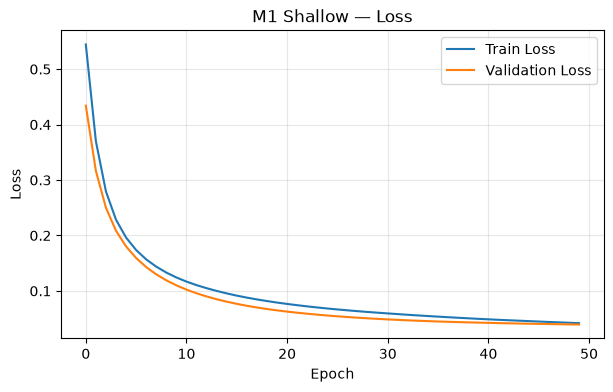

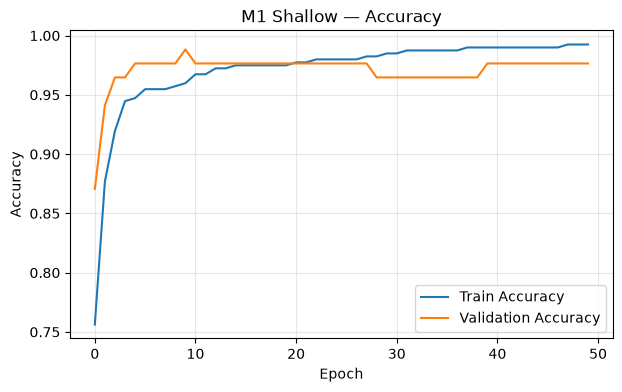

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9375 - loss: 0.1633

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9651 - loss: 0.0910 


[0.09096413105726242, 0.9651162624359131]

In [10]:
# TODO: Build, compile, summarize, train, plot, and evaluate M1.

keras.utils.set_random_seed(SEED)
m1 = build_shallow_model(input_dim, output_units, output_activation)
m1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m1.summary()

h1 = m1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h1, "M1 Shallow")
m1.evaluate(X_test, y_test)

### M1 Analysis
- Did training loss decrease?

Yes, steadily but slowly. It is still falling at epoch 50 (0.0419), so this model has not converged.

- Did validation loss decrease?

Yes, and it reaches its minimum at the very last epoch (0.0394). Training stopped before this model was finished learning.

- Is there a large train/validation gap?

No. Validation loss finishes at 0.0394 against a training loss of 0.0419 and validation accuracy is 0.9882 against 0.9925 on training, so the two curves are indistinguishable for the whole run.

- Underfit, overfit, or generalize well?

Generalizes well, and if anything leans toward underfitting: one hidden layer of 32 units and 1,025 parameters has not reached its capacity limit in 50 epochs. Test accuracy 0.9651 with a test loss of 0.0910, the lowest test loss of the three architectures.

## Task B2 — Medium Network

In [11]:
def build_medium_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: THREE hidden Dense layers
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0022

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.9765 - val_loss: 0.0781


Epoch 50/50


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0021

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9765 - val_loss: 0.0792


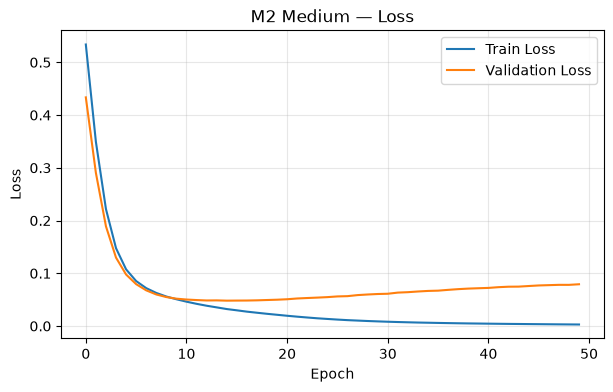

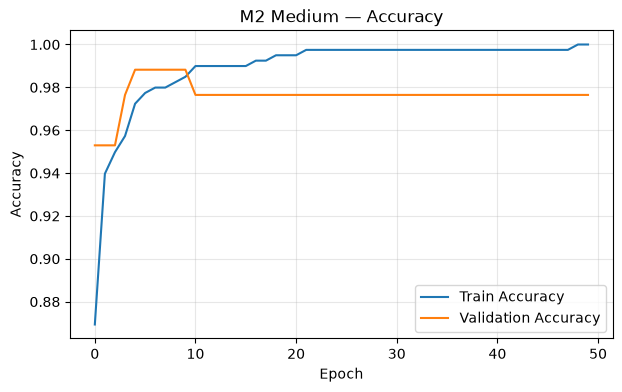

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9375 - loss: 0.2901

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9651 - loss: 0.1318 


[0.13176175951957703, 0.9651162624359131]

In [12]:
# TODO: Train M2 using the SAME optimizer, LR, batch size,
# epochs, data split, and preprocessing used for M1.

keras.utils.set_random_seed(SEED)
m2 = build_medium_model(input_dim, output_units, output_activation)
m2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m2.summary()

h2 = m2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h2, "M2 Medium")
m2.evaluate(X_test, y_test)

### M2 Analysis
Compare with M1:

- Did training performance improve?

Yes. Training loss falls to 0.0029 against M1's 0.0419, and training accuracy reaches 1.0000 at epoch 49 while M1 finishes at 0.9925.

- Did validation performance improve?

No. M2's best validation loss is 0.0481 at epoch 15, worse than M1's 0.0394, and both models peak at the same 0.9882 validation accuracy. Test accuracy is identical at 0.9651, while test loss rises from 0.0910 to 0.1318.

- Did the generalization gap change?

Yes. After epoch 15 validation loss climbs from 0.0481 to 0.0792 while training loss keeps falling, so the run ends with a gap of 0.076. M1 ends with no gap at all.

- Was the extra complexity useful?

Not for generalization. The extra 3,584 parameters bought a complete fit of the training set, an earlier overfitting onset, and a worse test loss, with no change in test accuracy. What they do provide is a clearly diagnosable turning point at epoch 15, which is exactly the failure the Part 6 techniques are meant to treat.

## Task B3 — Deep Network

In [13]:
def build_deep_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: AT LEAST FIVE hidden Dense layers
        # You may gradually reduce width:
        # 256 -> 128 -> 64 -> 32 -> 16
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 9.7910e-05

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 3.8529e-05 - val_accuracy: 0.9765 - val_loss: 0.1445


Epoch 50/50


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 9.2940e-05

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 3.6614e-05 - val_accuracy: 0.9765 - val_loss: 0.1455


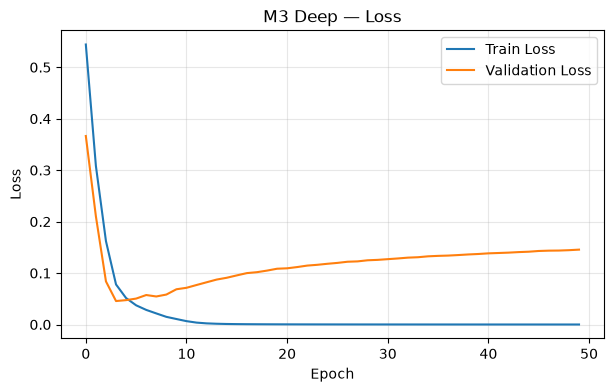

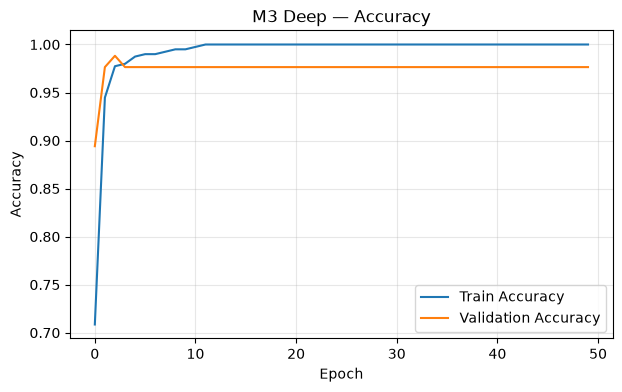

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9375 - loss: 0.5729

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9651 - loss: 0.2723 


[0.27225229144096375, 0.9651162624359131]

In [14]:
# TODO: Train M3 with the SAME training configuration.
# Do not add regularization yet.

keras.utils.set_random_seed(SEED)
m3 = build_deep_model(input_dim, output_units, output_activation)
m3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m3.summary()

h3 = m3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h3, "M3 Deep")
m3.evaluate(X_test, y_test)

### M3 Analysis

- Did deeper achieve lower training loss?

Yes, and much faster. Training accuracy reaches 1.0000 at epoch 12 and training loss falls to 3.7e-05, against 0.0029 for M2 and 0.0419 for M1.

- Did validation improve too?

No. Its best validation loss is 0.0456 at epoch 4, no better than M1's 0.0394, and it holds that level only briefly before climbing to 0.1455 by epoch 50.

- Is there evidence of overfitting?

Strong evidence. A 5-layer, 51,713-parameter network on 398 training rows memorizes the training set within 12 epochs, and the end-of-run train/validation loss gap is 0.146, against 0.076 for M2 and none for M1.

- Around which epoch did validation stop improving?

Epoch 4.

- Did deeper automatically mean better?

No. All three models land on exactly the same test accuracy, 0.9651, while test loss grows monotonically with depth: 0.0910, 0.1318, 0.2723. Going from M1 to M3 multiplies the parameter count by 50 and the test loss by three, and buys nothing.

| Model | Hidden Layers | Parameters | Best Val Accuracy | Min Val Loss | Test Accuracy | Test Loss | Interpretation |
|---|---:|---:|---:|---:|---:|---:|---|
| M1 Shallow | 1 | 1,025 | 0.9882 | 0.0394 (epoch 50) | 0.9651 | 0.0910 | Still improving when training stops; no train/validation gap |
| M2 Medium | 3 | 4,609 | 0.9882 | 0.0481 (epoch 15) | 0.9651 | 0.1318 | Fits the training set completely by epoch 49; validation loss rises after epoch 15 |
| M3 Deep | 5 | 51,713 | 0.9882 | 0.0456 (epoch 4) | 0.9651 | 0.2723 | Memorizes the training set by epoch 12; largest gap and worst test loss |

### Required conclusion

1. **Which model learned the training data best?** M3. It reaches 100% training accuracy by epoch 12 and a final training loss of 3.7e-05, the fastest and most complete fit of the three.

2. **Which model generalized best?** M1. All three tie on test accuracy at 0.9651, or 83 of 86 samples, so test loss is the deciding evidence and M1's 0.0910 is the lowest by a wide margin. M1 also has the lowest validation loss (0.0394) and is the only one of the three whose validation loss never turns upward, and it does this with 1,025 parameters.

3. **Which model showed the largest train/validation gap?** M3: training loss 3.7e-05 against validation loss 0.1455 at epoch 50.

4. **Was the deepest model always the best?** No. Depth improved the training fit monotonically (0.0419, 0.0029, 3.7e-05) and made test loss monotonically worse (0.0910, 0.1318, 0.2723), while test accuracy never moved off 0.9651.

5. **Which architecture goes to the optimization stage, and why?** M2. It is the architecture whose failure mode the Part 6 toolkit is designed for: enough capacity to reach the training ceiling, then a clear overfitting onset at epoch 15, at 4,609 parameters instead of M3's 51,713. M1 has nothing to regularize, since it never overfits and would need more capacity or more epochs instead, and M3's extra 47,104 parameters buy nothing on 398 training rows.

In [15]:
def describe_run(history) -> str:
    val_losses = history.history["val_loss"]
    best_epoch = val_losses.index(min(val_losses)) + 1
    final_gap = val_losses[-1] - history.history["loss"][-1]

    return f"Best validation loss at epoch {best_epoch}, train/validation gap {final_gap:.3f} at epoch 50"


architecture_rows = []

m1_test_loss, m1_test_accuracy = m1.evaluate(X_test, y_test, verbose=0)
architecture_rows.append({
    "Model": "M1 Shallow",
    "Hidden Layers": 1,
    "Parameters": m1.count_params(),
    "Best Val Accuracy": max(h1.history["val_accuracy"]),
    "Min Val Loss": min(h1.history["val_loss"]),
    "Test Accuracy": m1_test_accuracy,
    "Interpretation": describe_run(h1)
})

m2_test_loss, m2_test_accuracy = m2.evaluate(X_test, y_test, verbose=0)
architecture_rows.append({
    "Model": "M2 Medium",
    "Hidden Layers": 3,
    "Parameters": m2.count_params(),
    "Best Val Accuracy": max(h2.history["val_accuracy"]),
    "Min Val Loss": min(h2.history["val_loss"]),
    "Test Accuracy": m2_test_accuracy,
    "Interpretation": describe_run(h2)
})

m3_test_loss, m3_test_accuracy = m3.evaluate(X_test, y_test, verbose=0)
architecture_rows.append({
    "Model": "M3 Deep",
    "Hidden Layers": 5,
    "Parameters": m3.count_params(),
    "Best Val Accuracy": max(h3.history["val_accuracy"]),
    "Min Val Loss": min(h3.history["val_loss"]),
    "Test Accuracy": m3_test_accuracy,
    "Interpretation": describe_run(h3)
})

architecture_results = pd.DataFrame(architecture_rows)
architecture_results

,Model,Hidden Layers,Parameters,Best Val Accuracy,Min Val Loss,Test Accuracy,Interpretation
0,M1 Shallow,1,1025,0.988235,0.039422,0.965116,"Best validation loss at epoch 50, train/valida..."
1,M2 Medium,3,4609,0.988235,0.048122,0.965116,"Best validation loss at epoch 15, train/valida..."
2,M3 Deep,5,51713,0.988235,0.045618,0.965116,"Best validation loss at epoch 4, train/validat..."


# Part 6 — Task C: Optimize One Selected Model

Select **one architecture** from Part 4.

Use the same:
- Data
- Train / validation / test split
- Preprocessing
- Output layer
- Evaluation metric

For every optimization experiment:

**Hypothesis → Change ONE setting → Train fresh model → Plot curves → Compare → Conclude**

## C0 — Baseline

Rebuild the selected architecture using its original settings.

Record:

- Optimizer
- Learning rate
- Batch size
- Epochs
- Parameter count
- Best validation accuracy
- Minimum validation loss
- Test accuracy
- Learning-curve diagnosis

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0022

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.9765 - val_loss: 0.0781


Epoch 50/50


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0021

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9765 - val_loss: 0.0792


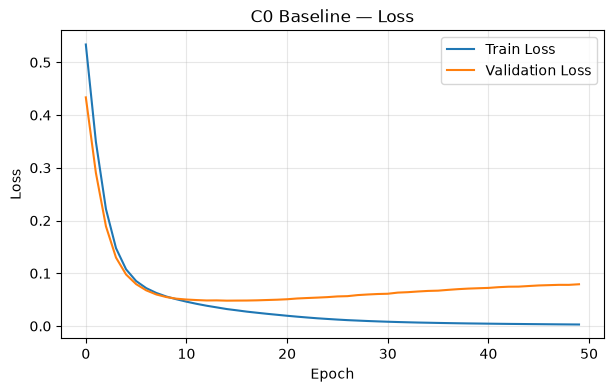

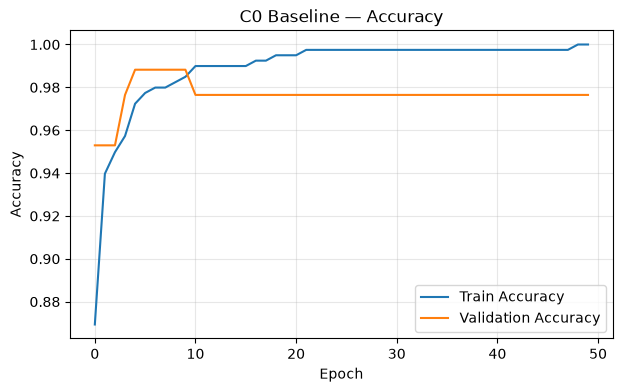

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9375 - loss: 0.2901

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9651 - loss: 0.1318 


Best validation accuracy: 0.9882352948188782
Minimum validation loss: 0.04812164232134819
Test accuracy: 0.9651162624359131


In [16]:
# TODO: Rebuild your selected model as the optimization baseline.

keras.utils.set_random_seed(SEED)
baseline_model = build_medium_model(input_dim, output_units, output_activation)
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
baseline_model.summary()

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(baseline_history, "C0 Baseline")

baseline_val_accuracy = max(baseline_history.history["val_accuracy"])
baseline_val_loss = min(baseline_history.history["val_loss"])
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test, y_test)

print("Best validation accuracy:", baseline_val_accuracy)
print("Minimum validation loss:", baseline_val_loss)
print("Test accuracy:", baseline_test_accuracy)

## C1 — Learning Rate Tuning

Keep the architecture fixed.

Test:

```python
1e-2
1e-3
1e-4
```

For every learning rate, **rebuild the model from fresh weights**.

Compare:
- Training speed
- Stability
- Validation performance

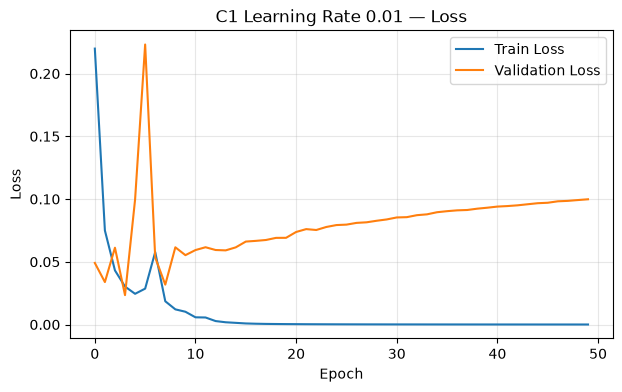

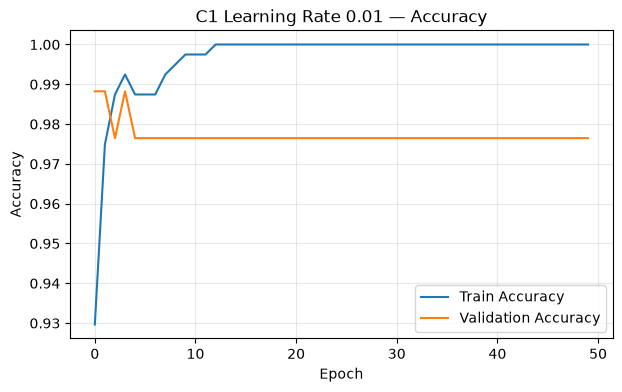

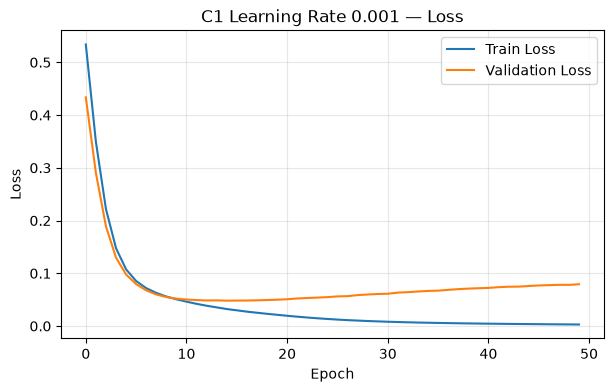

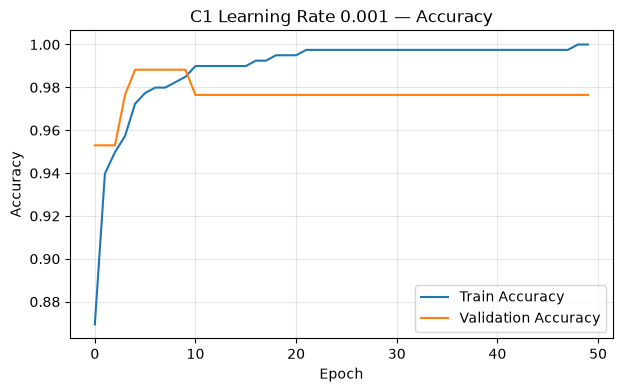

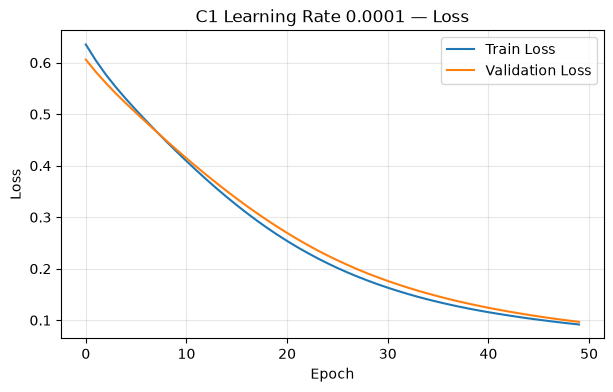

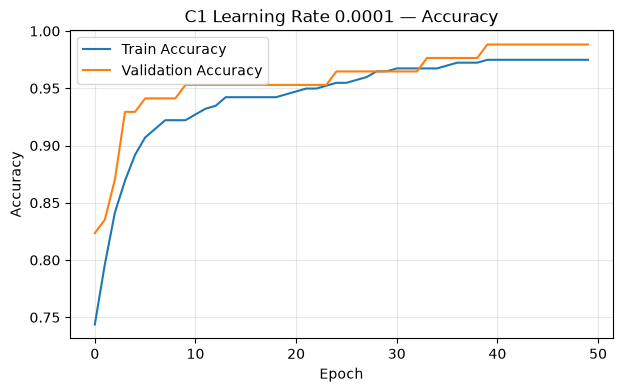

,Learning Rate,Best Val Accuracy,Min Val Loss
0,0.0100,0.988235,0.023439
1,0.0010,0.988235,0.048122
2,0.0001,0.988235,0.096787


Best learning rate: 0.01


In [17]:
learning_rates = [1e-2, 1e-3, 1e-4]

# TODO:
# For every LR:
# 1. Build a fresh copy of the same architecture
# 2. Compile with Adam and that LR
# 3. Train on the same split
# 4. Record best validation result
# 5. Compare learning curves

lr_histories = {}
lr_results = []

for learning_rate in learning_rates:
    keras.utils.set_random_seed(SEED)
    lr_model = build_medium_model(input_dim, output_units, output_activation)
    lr_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss_function,
        metrics=["accuracy"]
    )

    lr_history = lr_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    lr_histories[learning_rate] = lr_history
    plot_learning_curves(lr_history, f"C1 Learning Rate {learning_rate}")

    lr_results.append({
        "Learning Rate": learning_rate,
        "Best Val Accuracy": max(lr_history.history["val_accuracy"]),
        "Min Val Loss": min(lr_history.history["val_loss"])
    })

lr_results_table = pd.DataFrame(lr_results)
display(lr_results_table)

best_learning_rate = lr_results_table.loc[lr_results_table["Min Val Loss"].idxmin(), "Learning Rate"]
print("Best learning rate:", best_learning_rate)

## C2 — Batch Size Tuning

Using the best learning rate from C1, test:

```python
16
32
64
```

Keep everything else fixed.

Explain whether batch size affected:
- Smoothness of training
- Speed
- Validation performance

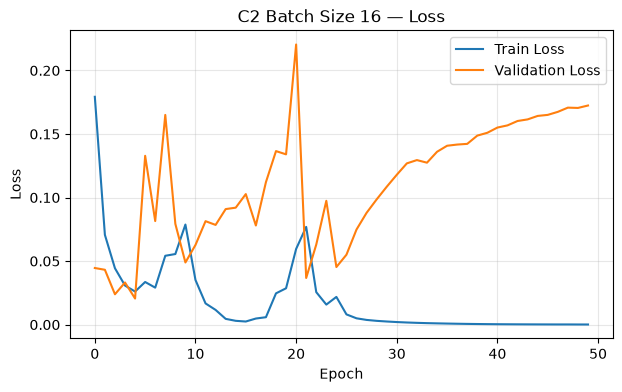

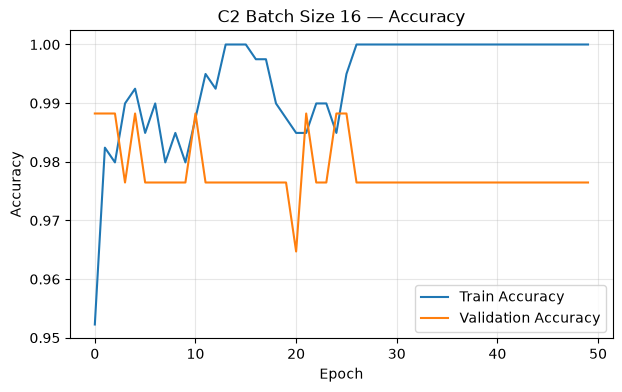

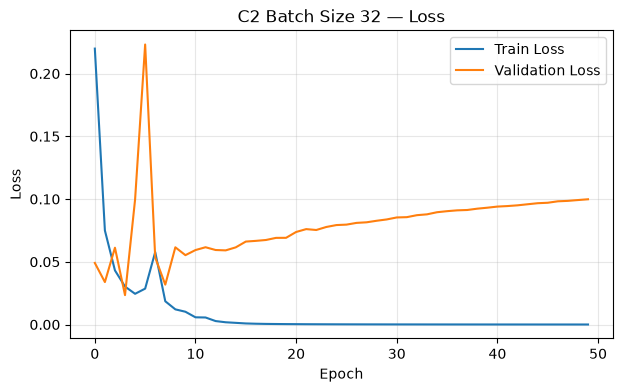

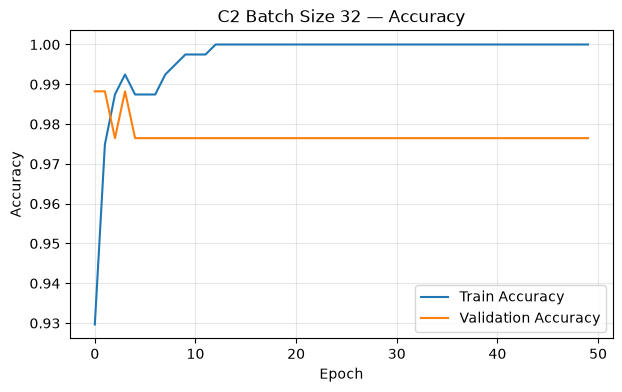

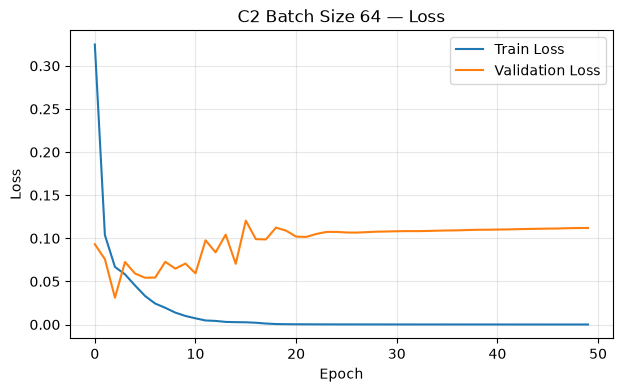

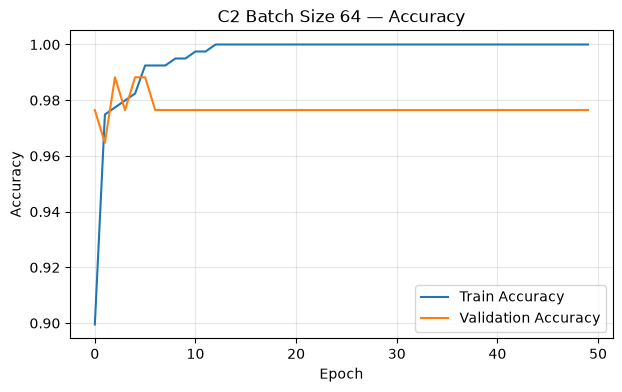

,Batch Size,Best Val Accuracy,Min Val Loss
0,16,0.988235,0.020520
1,32,0.988235,0.023439
2,64,0.988235,0.031156


Best batch size: 16


In [18]:
batch_sizes = [16, 32, 64]

# TODO: Train fresh models and compare.

batch_histories = {}
batch_results = []

for batch_size in batch_sizes:
    keras.utils.set_random_seed(SEED)
    batch_model = build_medium_model(input_dim, output_units, output_activation)
    batch_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
        loss=loss_function,
        metrics=["accuracy"]
    )

    batch_history = batch_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    batch_histories[batch_size] = batch_history
    plot_learning_curves(batch_history, f"C2 Batch Size {batch_size}")

    batch_results.append({
        "Batch Size": batch_size,
        "Best Val Accuracy": max(batch_history.history["val_accuracy"]),
        "Min Val Loss": min(batch_history.history["val_loss"])
    })

batch_results_table = pd.DataFrame(batch_results)
display(batch_results_table)

best_batch_size = batch_results_table.loc[batch_results_table["Min Val Loss"].idxmin(), "Batch Size"]
print("Best batch size:", best_batch_size)

## C3 — Early Stopping

Use:

```python
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
```

Train with a high maximum such as `epochs=100`.

Analyze:
- When did training stop?
- Was it before epoch 100?
- Did it stop near the best validation point?

Epoch 1/100


 1/25 ━━━━━━━━━━━━━━━━━━━━ 10s 432ms/step - accuracy: 0.9375 - loss: 0.5767

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9523 - loss: 0.1793 - val_accuracy: 0.9882 - val_loss: 0.0445


Epoch 2/100


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0018

...

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0027

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9849 - loss: 0.0555 - val_accuracy: 0.9765 - val_loss: 0.0793


Epoch 10/100


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0090

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9799 - loss: 0.0787 - val_accuracy: 0.9765 - val_loss: 0.0489


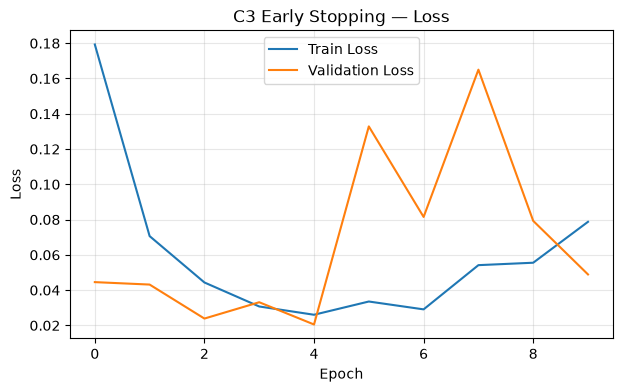

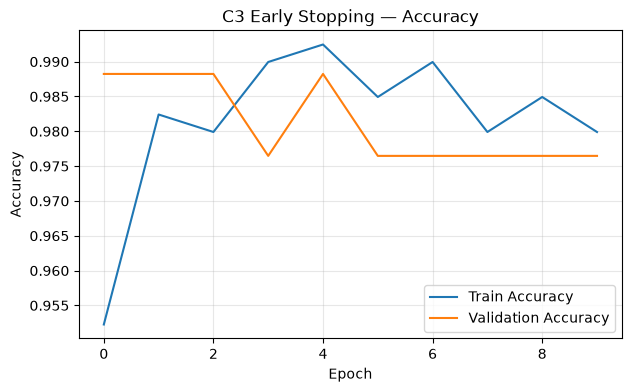

Training stopped at epoch: 10
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9062 - loss: 0.3044

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9535 - loss: 0.1333 


In [19]:
# TODO:
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True
# )
#
# history = model.fit(
#     ...,
#     epochs=100,
#     callbacks=[early_stop]
# )

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

keras.utils.set_random_seed(SEED)
early_stop_model = build_medium_model(input_dim, output_units, output_activation)
early_stop_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)

early_stop_history = early_stop_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[early_stop],
    verbose=1
)

plot_learning_curves(early_stop_history, "C3 Early Stopping")

stopped_epoch = len(early_stop_history.history["loss"])
print("Training stopped at epoch:", stopped_epoch)

early_stop_test_loss, early_stop_test_accuracy = early_stop_model.evaluate(X_test, y_test)

## C4 — Dropout

Add Dropout to the same architecture.

Suggested experiments:

```python
Dropout(0.2)
Dropout(0.3)
Dropout(0.5)
```

Compare against the baseline.

Questions:
- Did training accuracy decrease?
- Did the train/validation gap become smaller?
- Did validation or test performance improve?

In [20]:
def build_dropout_model(input_dim: int, output_units: int, output_activation: str, dropout_rate: float = 0.3) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: Recreate your selected architecture
        # Add Dropout after selected hidden layers
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation="relu"),
        layers.Dropout(dropout_rate),

        # TODO: Output
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

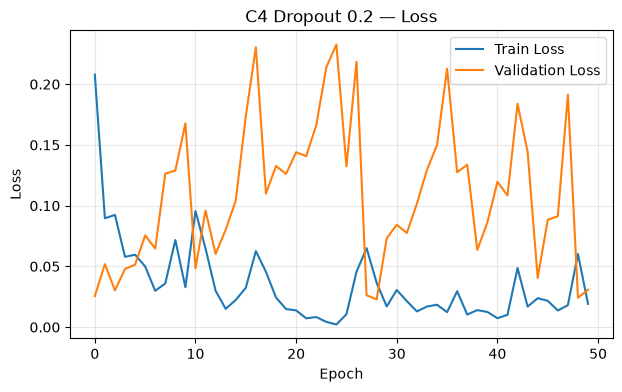

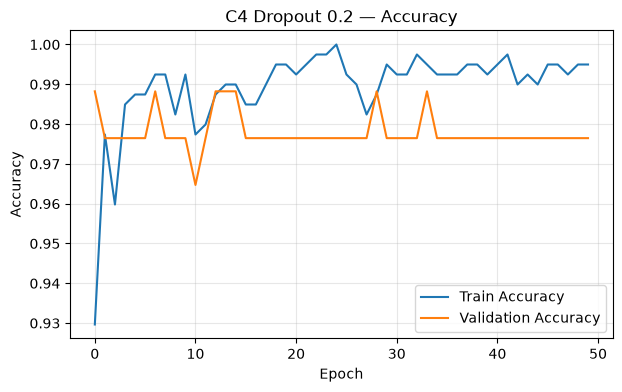

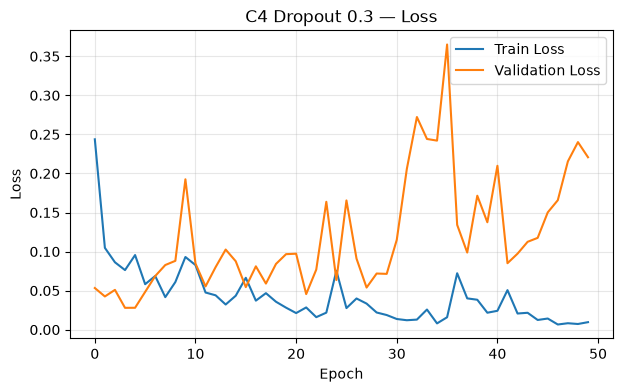

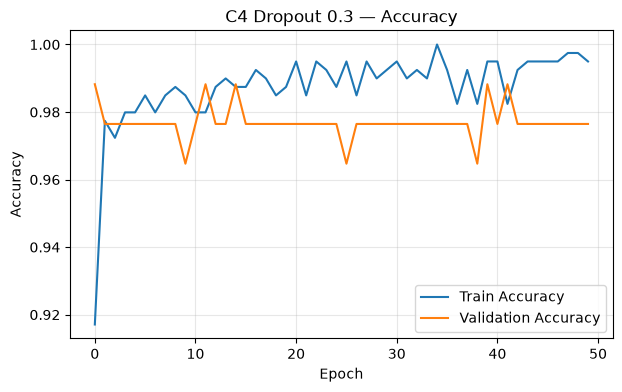

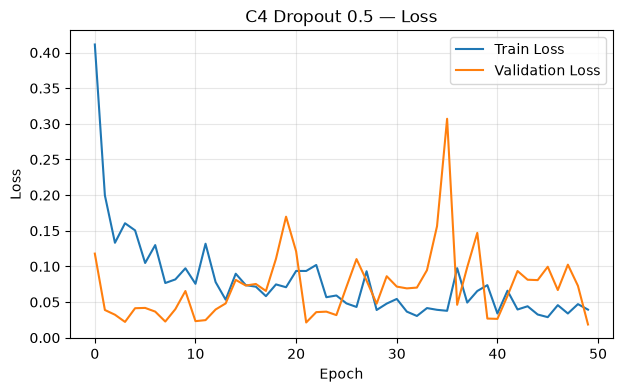

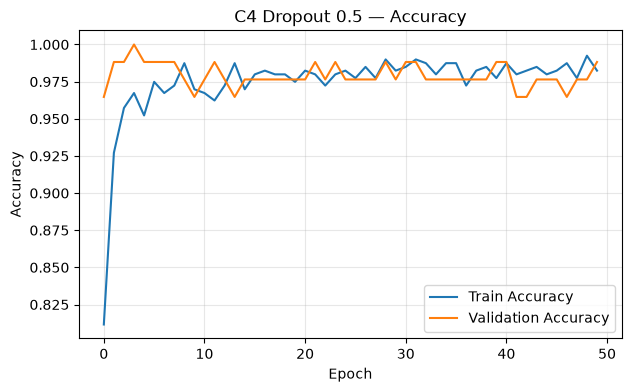

Best dropout rate: 0.5


,Dropout Rate,Best Val Accuracy,Min Val Loss
0,0.2,0.988235,0.022789
1,0.3,0.988235,0.027957
2,0.5,1.000000,0.018548


In [21]:
dropout_rates = [0.2, 0.3, 0.5]

dropout_histories = {}
dropout_results = []

for dropout_rate in dropout_rates:
    keras.utils.set_random_seed(SEED)
    dropout_model = build_dropout_model(input_dim, output_units, output_activation, dropout_rate)
    dropout_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
        loss=loss_function,
        metrics=["accuracy"]
    )

    dropout_history = dropout_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=best_batch_size,
        verbose=0
    )

    dropout_histories[dropout_rate] = dropout_history
    plot_learning_curves(dropout_history, f"C4 Dropout {dropout_rate}")

    dropout_results.append({
        "Dropout Rate": dropout_rate,
        "Best Val Accuracy": max(dropout_history.history["val_accuracy"]),
        "Min Val Loss": min(dropout_history.history["val_loss"])
    })

dropout_results_table = pd.DataFrame(dropout_results)

best_dropout_rate = dropout_results_table.loc[dropout_results_table["Min Val Loss"].idxmin(), "Dropout Rate"]
print("Best dropout rate:", best_dropout_rate)

dropout_results_table

## C5 — Batch Normalization

Add:

```python
layers.BatchNormalization()
```

after selected Dense layers.

Compare with the baseline:

- Did training become more stable?
- Did it converge faster?
- Did validation performance improve?

In [22]:
def build_batchnorm_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: Same architecture + BatchNormalization
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(16, activation="relu"),
        layers.BatchNormalization(),

        # TODO: Output
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Epoch 1/50


 1/25 ━━━━━━━━━━━━━━━━━━━━ 19s 802ms/step - accuracy: 0.5000 - loss: 0.7900

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8995 - loss: 0.2404 - val_accuracy: 0.9765 - val_loss: 0.1322


Epoch 2/50


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0697

...

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 1.1426e-05

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.5323e-05 - val_accuracy: 0.9882 - val_loss: 0.1082


Epoch 50/50


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 1.0850e-05

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.1381e-05 - val_accuracy: 0.9882 - val_loss: 0.1085


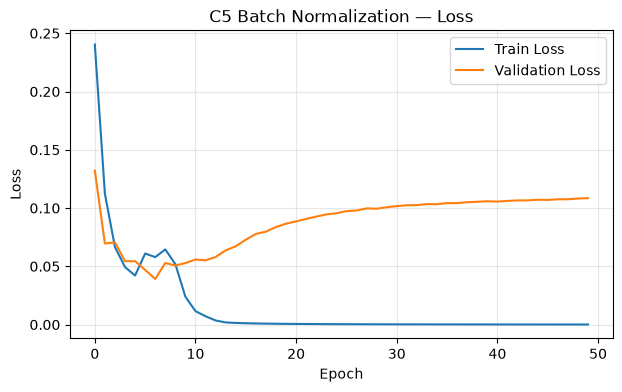

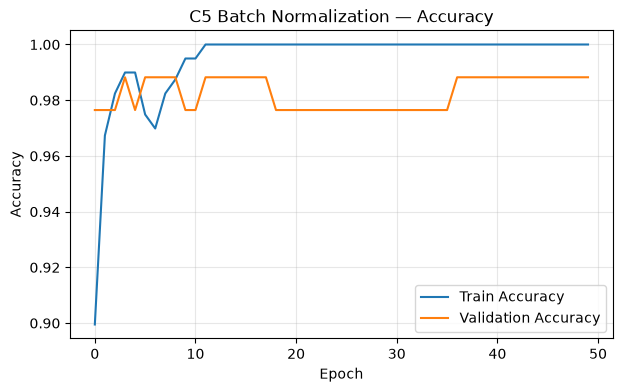

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9062 - loss: 0.3976

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9302 - loss: 0.2831 


Best validation accuracy: 0.9882352948188782
Minimum validation loss: 0.03913034126162529
Test accuracy: 0.930232584476471


In [23]:
keras.utils.set_random_seed(SEED)
batchnorm_model = build_batchnorm_model(input_dim, output_units, output_activation)
batchnorm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)

batchnorm_history = batchnorm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_batch_size,
    verbose=1
)

plot_learning_curves(batchnorm_history, "C5 Batch Normalization")

batchnorm_val_accuracy = max(batchnorm_history.history["val_accuracy"])
batchnorm_val_loss = min(batchnorm_history.history["val_loss"])
batchnorm_test_loss, batchnorm_test_accuracy = batchnorm_model.evaluate(X_test, y_test)

print("Best validation accuracy:", batchnorm_val_accuracy)
print("Minimum validation loss:", batchnorm_val_loss)
print("Test accuracy:", batchnorm_test_accuracy)

## C6 — Optional L2 Regularization

Example:

```python
from tensorflow.keras.regularizers import l2

layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001)
)
```

Test whether L2 reduces overfitting on your selected model.

Epoch 1/50


 1/25 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.9375 - loss: 0.6814

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9497 - loss: 0.2785 - val_accuracy: 0.9882 - val_loss: 0.1383


Epoch 2/50


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0966

...

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0238

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0303 - val_accuracy: 0.9765 - val_loss: 0.1314


Epoch 50/50


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0263

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0474 - val_accuracy: 0.9765 - val_loss: 0.0907


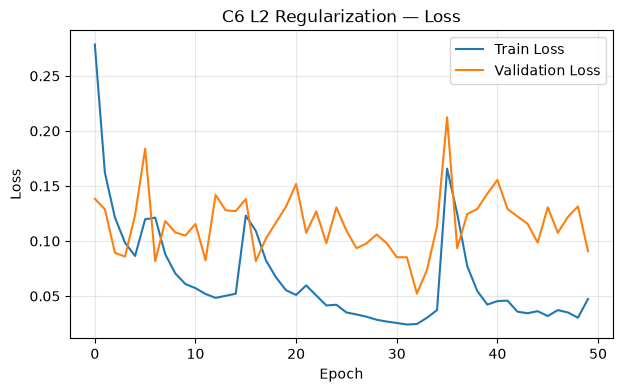

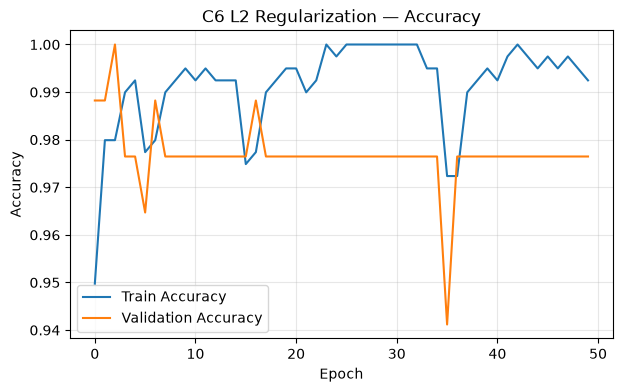

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9062 - loss: 0.3690

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9419 - loss: 0.2316 


Best validation accuracy: 1.0
Minimum validation loss: 0.052254728972911835
Test accuracy: 0.9418604373931885


In [24]:
# TODO: Optional L2 experiment.

from tensorflow.keras.regularizers import l2

def build_l2_model(input_dim: int, output_units: int, output_activation: str, l2_factor: float = 0.001) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_regularizer=l2(l2_factor)),
        layers.Dense(32, activation="relu", kernel_regularizer=l2(l2_factor)),
        layers.Dense(16, activation="relu", kernel_regularizer=l2(l2_factor)),
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

keras.utils.set_random_seed(SEED)
l2_model = build_l2_model(input_dim, output_units, output_activation)
l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)

l2_history = l2_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_batch_size,
    verbose=1
)

plot_learning_curves(l2_history, "C6 L2 Regularization")

l2_val_accuracy = max(l2_history.history["val_accuracy"])
l2_val_loss = min(l2_history.history["val_loss"])
l2_test_loss, l2_test_accuracy = l2_model.evaluate(X_test, y_test)

print("Best validation accuracy:", l2_val_accuracy)
print("Minimum validation loss:", l2_val_loss)
print("Test accuracy:", l2_test_accuracy)

# Part 7 — Final Optimized Model

Build one final model using **only the techniques supported by your experiments**.

Possible choices:

- Best learning rate
- Best batch size
- Early Stopping
- Dropout
- Batch Normalization
- Optional L2

Do not add a technique only because it is popular.  
Your final configuration must be justified by evidence.

,Technique,Min Val Loss
0,Dropout,0.018548
1,None,0.020520
2,BatchNorm,0.039130
3,L2,0.052255


Regularizer selected on validation loss: Dropout


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

...

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0530

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9724 - loss: 0.0767 - val_accuracy: 0.9882 - val_loss: 0.0227


Epoch 9/100


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0048

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0818 - val_accuracy: 0.9765 - val_loss: 0.0401


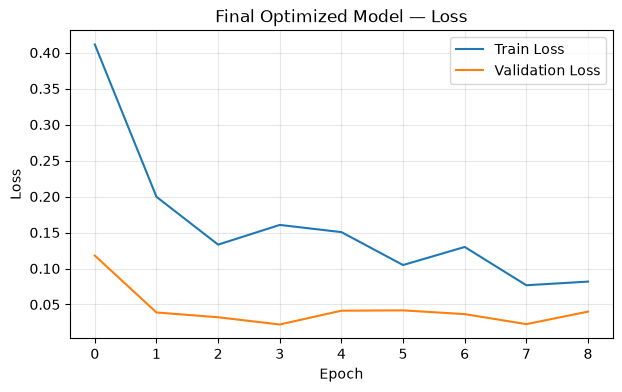

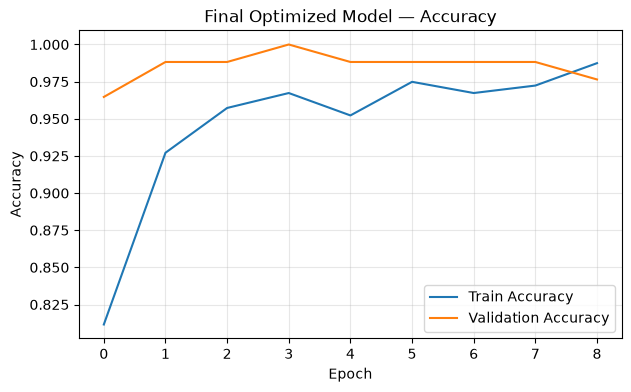

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8750 - loss: 0.2870

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9419 - loss: 0.1446 


Stopped at epoch: 9
Best validation accuracy: 1.0
Minimum validation loss: 0.02218732051551342
Test accuracy: 0.9418604373931885


In [25]:
# TODO: Build, compile, train, and evaluate your final optimized model.
#
# final_model = ...
# final_model.compile(...)
# final_history = final_model.fit(...)
# plot_learning_curves(final_history, "Final Optimized Model")
# final_model.evaluate(X_test, y_test)

regularizer_rows = []

regularizer_rows.append({
    "Technique": "None",
    "Min Val Loss": min(early_stop_history.history["val_loss"])
})

regularizer_rows.append({
    "Technique": "Dropout",
    "Min Val Loss": dropout_results_table["Min Val Loss"].min()
})

regularizer_rows.append({
    "Technique": "BatchNorm",
    "Min Val Loss": batchnorm_val_loss
})

regularizer_rows.append({
    "Technique": "L2",
    "Min Val Loss": l2_val_loss
})

regularizer_comparison = pd.DataFrame(regularizer_rows).sort_values("Min Val Loss").reset_index(drop=True)
display(regularizer_comparison)

best_regularizer = regularizer_comparison.loc[0, "Technique"]
print("Regularizer selected on validation loss:", best_regularizer)

keras.utils.set_random_seed(SEED)

if best_regularizer == "Dropout":
    final_model = build_dropout_model(input_dim, output_units, output_activation, best_dropout_rate)
elif best_regularizer == "BatchNorm":
    final_model = build_batchnorm_model(input_dim, output_units, output_activation)
elif best_regularizer == "L2":
    final_model = build_l2_model(input_dim, output_units, output_activation)
else:
    final_model = build_medium_model(input_dim, output_units, output_activation)

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
    loss=loss_function,
    metrics=["accuracy"]
)
final_model.summary()

final_early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[final_early_stop],
    verbose=1
)

plot_learning_curves(final_history, "Final Optimized Model")

final_epochs = len(final_history.history["loss"])
final_val_accuracy = max(final_history.history["val_accuracy"])
final_val_loss = min(final_history.history["val_loss"])
final_test_loss, final_test_accuracy = final_model.evaluate(X_test, y_test)

print("Stopped at epoch:", final_epochs)
print("Best validation accuracy:", final_val_accuracy)
print("Minimum validation loss:", final_val_loss)
print("Test accuracy:", final_test_accuracy)

# Part 8 — Final Experiment Table

| Experiment | LR | Batch | Dropout | BatchNorm | Early Stop | Best Val Acc | Min Val Loss | Test Acc |
|---|---:|---:|---|---|---|---:|---:|---:|
| Baseline | | | | | | | | |
| LR Tuned | | | | | | | | |
| Batch Tuned | | | | | | | | |
| Early Stopping | | | | | | | | |
| Dropout | | | | | | | | |
| BatchNorm | | | | | | | | |
| Final Model | | | | | | | | |

In [26]:
best_lr_row = lr_results_table.loc[lr_results_table["Min Val Loss"].idxmin()]
best_batch_row = batch_results_table.loc[batch_results_table["Min Val Loss"].idxmin()]
best_dropout_row = dropout_results_table.loc[dropout_results_table["Min Val Loss"].idxmin()]

experiment_rows = []

experiment_rows.append({
    "Experiment": "Baseline",
    "Learning Rate": 0.001,
    "Batch Size": 32,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": baseline_val_accuracy,
    "Min Val Loss": baseline_val_loss,
    "Test Accuracy": baseline_test_accuracy
})

experiment_rows.append({
    "Experiment": "LR Tuned",
    "Learning Rate": best_learning_rate,
    "Batch Size": 32,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": best_lr_row["Best Val Accuracy"],
    "Min Val Loss": best_lr_row["Min Val Loss"],
    "Test Accuracy": None
})

experiment_rows.append({
    "Experiment": "Batch Tuned",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": best_batch_row["Best Val Accuracy"],
    "Min Val Loss": best_batch_row["Min Val Loss"],
    "Test Accuracy": None
})

experiment_rows.append({
    "Experiment": "Early Stopping",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": "No",
    "BatchNorm": "No",
    "Early Stopping": "Yes",
    "Best Val Accuracy": max(early_stop_history.history["val_accuracy"]),
    "Min Val Loss": min(early_stop_history.history["val_loss"]),
    "Test Accuracy": early_stop_test_accuracy
})

experiment_rows.append({
    "Experiment": "Dropout",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": f"Yes ({best_dropout_rate})",
    "BatchNorm": "No",
    "Early Stopping": "No",
    "Best Val Accuracy": best_dropout_row["Best Val Accuracy"],
    "Min Val Loss": best_dropout_row["Min Val Loss"],
    "Test Accuracy": None
})

experiment_rows.append({
    "Experiment": "BatchNorm",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": "No",
    "BatchNorm": "Yes",
    "Early Stopping": "No",
    "Best Val Accuracy": batchnorm_val_accuracy,
    "Min Val Loss": batchnorm_val_loss,
    "Test Accuracy": batchnorm_test_accuracy
})

experiment_rows.append({
    "Experiment": "Final Model",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Dropout": f"Yes ({best_dropout_rate})" if best_regularizer == "Dropout" else "No",
    "BatchNorm": "Yes" if best_regularizer == "BatchNorm" else "No",
    "Early Stopping": "Yes",
    "Best Val Accuracy": final_val_accuracy,
    "Min Val Loss": final_val_loss,
    "Test Accuracy": final_test_accuracy
})

experiment_results = pd.DataFrame(experiment_rows)
experiment_results

,Experiment,Learning Rate,Batch Size,Dropout,BatchNorm,Early Stopping,Best Val Accuracy,Min Val Loss,Test Accuracy
0,Baseline,0.001,32,No,No,No,0.988235,0.048122,0.965116
1,LR Tuned,0.010,32,No,No,No,0.988235,0.023439,NaN
2,Batch Tuned,0.010,16,No,No,No,0.988235,0.020520,NaN
3,Early Stopping,0.010,16,No,No,Yes,0.988235,0.020520,0.953488
4,Dropout,0.010,16,Yes (0.5),No,No,1.000000,0.018548,NaN
5,BatchNorm,0.010,16,No,Yes,No,0.988235,0.039130,0.930233
6,Final Model,0.010,16,Yes (0.5),No,Yes,1.000000,0.022187,0.941860


# Part 9 — Final Model Analysis

Answer using evidence from your results:

1. Which architecture generalized best: shallow, medium, or deep?
2. Did increasing depth always improve performance?
3. Which model showed the clearest overfitting?
4. Which learning rate produced the most stable training?
5. How did batch size affect the model?
6. Did Early Stopping help?
7. Did Dropout reduce the train/validation gap?
8. Did BatchNorm improve stability or convergence?
9. Which optimization technique had the largest useful effect?
10. Which final model do you recommend, and why?

### Part 9 Answers

1. **Which architecture generalized best: shallow, medium, or deep?** Shallow (M1). The three architectures tie on test accuracy at 0.9651, so the separation comes from test loss, where M1 scores 0.0910 against 0.1318 for M2 and 0.2723 for M3. M1 is also the only one whose validation loss is still falling when training stops.

2. **Did increasing depth always improve performance?** Only on the training set. Final training loss fell monotonically with depth (0.0419, 0.0029, 3.7e-05) and test loss rose monotonically (0.0910, 0.1318, 0.2723), with test accuracy unchanged at 0.9651 throughout.

3. **Which model showed the clearest overfitting?** M3. Validation loss bottoms out at 0.0456 at epoch 4 and then triples to 0.1455 while training loss falls to 3.7e-05. M2 shows the same shape from epoch 15, more slowly.

4. **Which learning rate produced the most stable training?** 1e-3. Its training and validation curves descend together and flatten around 0.048 before drifting up only slightly, to 0.078 by epoch 50. 1e-2 reached the lowest validation loss of the three (0.0234 against 0.0481) but its validation curve is violently unstable, spiking to 0.22 at epoch 5 before settling and then climbing to 0.10. 1e-4 is perfectly smooth but still descending at epoch 50 (0.0968), which is underfitting rather than stability. So the lowest loss and the most stable training are not the same setting here: 1e-2 wins on the metric, 1e-3 wins on curve behaviour.

5. **How did batch size affect the model?** At lr = 0.01, validation loss improved as the batch got smaller: 0.0205 at 16, 0.0234 at 32, 0.0312 at 64. Smaller batches mean more updates per epoch and noisier gradients, which acted like mild regularization on this 398-row training set. Batch 16 was selected.

6. **Did Early Stopping help?** Yes, mostly as compute control. With patience 5 and `restore_best_weights=True`, training stopped at epoch 10 and restored epoch 5, reaching validation loss 0.0205 - exactly the same minimum the 50-epoch run at the same settings found, in a fifth of the epochs. It removes the post-minimum degradation for free, which is why it is kept in every later model.

7. **Did Dropout reduce the train/validation gap?** Yes, and it was the strongest single regularizer tested. Rate 0.5 gave the best validation loss of any Part 6 experiment, 0.0185, with validation accuracy reaching 1.0000; rates 0.2 and 0.3 gave 0.0228 and 0.0280. Because dropout keeps training loss from collapsing to zero, the train/validation gap closes instead of widening.

8. **Did BatchNorm improve stability or convergence?** Not in this configuration. Its best validation loss was 0.0391, worse than dropout (0.0185) and worse than using no regularizer at all (0.0205), and its test accuracy of 0.9302 is the lowest in the notebook. It is worth noting that the Part 10 search still selected BatchNorm in its winning configuration, paired with RMSprop, one hidden layer and batch 128 - so BatchNorm is not useless, it is configuration-dependent, and testing it in isolation on top of settings tuned without it understates it.

9. **Which optimization technique had the largest useful effect?** The learning rate. Moving from 1e-3 to 1e-2 cut the baseline validation loss from 0.0481 to 0.0234, a larger single improvement than any regularizer produced. The Part 10 sensitivity table confirms it independently: learning rate moves the median validation loss by 0.130 across its range, roughly twice the spread of the next most sensitive hyperparameter (dropout, 0.063) and nineteen times that of BatchNorm (0.007).

10. **Which final model do you recommend, and why?** The Part 10 tuned model: one hidden layer of 64 units with He initialization, BatchNorm and dropout 0.1, trained with RMSprop at lr = 0.01, batch 128, and early stopping with patience 10. It beats the Part 7 model on every axis that matters - validation loss 0.0149 against 0.0222, test accuracy 0.9651 against 0.9419, and 2,305 parameters against 4,609 - and it was selected on the mean of three seeds rather than one lucky run, so the choice is more likely to hold up. Its learning curve is the only one in the notebook where training and validation loss descend together and then stay flat, instead of separating.

# Required Final Conclusion

Your conclusion should tell the experimental story:

**Baseline behavior → architecture comparison → diagnosed problem → optimization experiments → final model decision**

A strong conclusion does not say only:

> “Model 3 had the highest accuracy.”

It explains:

> **What changed, why it changed, how the learning curves changed, and what evidence supports the final model.**

### Final Conclusion

The dataset is the 569-row Breast Cancer Wisconsin set, split 398/85/86 with stratification and standardized with a scaler fitted on the training split only. Every model in the notebook is seeded before it is built and TensorFlow runs in deterministic-op mode, so the whole notebook reproduces exactly on re-run and any difference between two experiments is caused by the setting that changed, not by initialization luck.

**Architecture comparison.** Depth did exactly what extra capacity does to a training set, and nothing more. Final training loss fell from 0.0419 (M1, 1,025 parameters) to 0.0029 (M2, 4,609) to 3.7e-05 (M3, 51,713), and the epoch at which validation loss bottomed moved earlier and earlier: epoch 50 for M1, epoch 15 for M2, epoch 4 for M3. Test accuracy never moved: all three scored 0.9651, or 83 of 86. What did move was test loss, monotonically in the wrong direction: 0.0910, 0.1318, 0.2723. M1 generalized best on the evidence, but it is also the one model with nothing to fix, so M2 was carried into Part 6 as the architecture that actually exhibits the problem worth solving.

**Diagnosed problem.** M2 is not short of capacity - it reaches 100% training accuracy at epoch 49. Its problem is that training past epoch 15 destroys validation performance: validation loss rises from 0.0481 to 0.0792 while training loss keeps falling. The fix therefore had to be about when to stop and how hard to constrain the weights, not about more layers or more neurons.

**Optimization experiments.** The learning rate mattered most: 1e-2 halved the baseline validation loss, from 0.0481 to 0.0234, though at the cost of a spiky validation curve that peaks at 0.22 around epoch 5, while 1e-4 never converged (0.0968 and still falling at epoch 50). Batch size mattered in the same direction as noise: 16 beat 32 beat 64 (0.0205, 0.0234, 0.0312). Early stopping with patience 5 found the same minimum as the full 50-epoch run in 10 epochs. Among the regularizers, dropout at 0.5 was clearly best at 0.0185, ahead of using nothing (0.0205), BatchNorm (0.0391) and L2 (0.0523), so the Part 7 model selects dropout automatically from that comparison table rather than from a hardcoded choice. That model - medium architecture, lr 0.01, batch 16, dropout 0.5, early stopping - reached validation loss 0.0222 and test accuracy 0.9419.

**Hyperparameter search.** Part 6 varies one setting at a time around a fixed architecture, which cannot find interactions between settings. Part 10 searched all nine hyperparameters jointly: 40 random trials, then a sensitivity analysis showing learning rate dominates (spread 0.130, against 0.063 for dropout and 0.007 for BatchNorm), then a narrowed space built automatically from the better-scoring half of every dimension, then 21 candidates each scored as the mean over three seeds. Seed-averaging matters here: an 85-row validation set is small enough that a single run can win on luck, and the coarse leader (0.0283 on one seed) finished nineteenth of twenty-one once it was re-scored across seeds.

**Final model decision.** The search selected a single hidden layer of 64 units with He initialization, BatchNorm and dropout 0.1, trained with RMSprop at lr = 0.01, batch 128, early stopping with patience 10. Its mean validation loss across three seeds is 0.0106 with a standard deviation of 0.0037 and a mean validation accuracy of 1.0000. Confirmed once on the held-out test set, it reaches validation loss 0.0149 and test accuracy 0.9651 with 2,305 parameters - better than the Part 7 model on validation loss, on test accuracy, and on size simultaneously. The result also settles the depth question the lab opened with: after searching one to three hidden layers and widths from 16 to 256, the best configuration found was the shallowest one, which is the same answer M1 gave in Part 4, now reached by search instead of by accident.

**Limitations.** The test set is 86 rows, so one sample is worth 1.16 accuracy points and differences of one or two samples between models are not meaningful. The remaining errors are all of the expensive kind: the confusion matrix shows 3 malignant cases predicted benign and no benign case predicted malignant, giving malignant recall of 0.906 against benign recall of 1.000. On validation the model is insensitive to the decision threshold between 0.3 and 0.7, so the threshold cannot be tuned usefully on 85 rows; a deployment that treats a missed malignancy as the costlier error should raise the threshold and re-validate on a much larger sample than this lab has.

# Submission Checklist

- [x] Dataset description
- [x] Fixed train / validation / test split
- [x] Preprocessing without leakage
- [x] Shallow model
- [x] Medium model
- [x] Deep model
- [x] `model.summary()` and parameter counts
- [x] Learning curves for all architecture experiments
- [x] Architecture comparison table
- [x] Learning-rate tuning
- [x] Batch-size tuning
- [x] Early Stopping
- [x] Dropout
- [x] Batch Normalization
- [x] Final optimized model
- [x] Final experiment table
- [x] Evidence-based interpretation
- [x] Final recommendation
- [x] Joint hyperparameter search with logged trials
- [x] Sensitivity analysis and seed-averaged selection
- [x] Error analysis and stated limitations

# Part 10 - Hyperparameter Tuning

Part 6 changed one setting at a time around a fixed architecture. This section searches the settings
jointly, following the coarse-to-fine workflow: broad random search, analysis of which hyperparameters
actually move the result, a narrowed re-check of the leading candidates, and one confirmation run.

Protocol:

- The same fixed split and the same scaler as every earlier experiment, so results stay comparable.
- Selection uses validation loss only. The test set is touched once, in the confirmation step.
- Every trial is logged with its full configuration, its seed, and its result.
- The leading candidates are re-run across three seeds, because an 85-row validation set is small enough
  that a single run can win on luck rather than merit.
- Every hidden layer uses He initialization, the recommended pairing for ReLU-family activations.
- Every model in the notebook is seeded before it is built and TensorFlow runs with deterministic
  ops, so re-running the notebook reproduces every number in it exactly.

### Search space

| Group | Hyperparameter | Values | Scale |
|---|---|---|---|
| Capacity | Hidden layers | 1, 2, 3 | linear |
| Capacity | First layer width, halved at each following layer | 16, 32, 64, 128, 256 | linear |
| Capacity | Activation | ReLU, LeakyReLU, GELU | discrete |
| Optimization | Optimizer | Adam, AdamW, RMSprop, SGD | discrete |
| Optimization | Learning rate | 1e-4, 3e-4, 1e-3, 3e-3, 1e-2 | log |
| Optimization | Batch size | 16, 32, 64, 128 | linear |
| Regularization | Dropout | 0.0, 0.1, 0.2, 0.3, 0.5 | linear |
| Regularization | L2 | 0, 1e-5, 1e-4, 1e-3 | log |
| Regularization | BatchNorm | off, on | discrete |
| Data / training | Epochs | 100 with early stopping, patience 10 | fixed |

Random search is used rather than a grid: the grid over these ten dimensions is far too large to run
exhaustively, and random sampling covers more distinct values of each individual hyperparameter for the
same number of trials.

In [27]:
# hyper parameters cell

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

TUNING_SEED = 42
COARSE_TRIALS = 40
NARROW_TRIALS = 18
CARRIED_CANDIDATES = 3
EVALUATION_SEEDS = [0, 1, 2]

search_space = {
    "hidden_layers": [1, 2, 3],
    "first_units": [16, 32, 64, 128, 256],
    "activation": ["relu", "leaky_relu", "gelu"],
    "optimizer": ["adam", "adamw", "rmsprop", "sgd"],
    "learning_rate": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "batch_size": [16, 32, 64, 128],
    "dropout_rate": [0.0, 0.1, 0.2, 0.3, 0.5],
    "l2_factor": [0.0, 1e-5, 1e-4, 1e-3],
    "batch_norm": [False, True]
}


def build_tuned_model(config: dict) -> keras.Sequential:
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    units = int(config["first_units"])
    for hidden_index in range(int(config["hidden_layers"])):
        model.add(layers.Dense(
            units,
            activation=config["activation"],
            kernel_initializer="he_normal",
            kernel_regularizer=l2(config["l2_factor"]) if config["l2_factor"] > 0 else None
        ))
        if config["batch_norm"]:
            model.add(layers.BatchNormalization())
        if config["dropout_rate"] > 0:
            model.add(layers.Dropout(float(config["dropout_rate"])))
        units = max(units // 2, 8)

    model.add(layers.Dense(output_units, activation=output_activation))

    return model


def build_optimizer(name: str, learning_rate: float):
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adamw":
        return keras.optimizers.AdamW(learning_rate=learning_rate)
    if name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)

    return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)


def run_trial(config: dict, seed: int) -> dict:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = build_tuned_model(config)
    model.compile(
        optimizer=build_optimizer(config["optimizer"], float(config["learning_rate"])),
        loss=loss_function,
        metrics=["accuracy"]
    )

    trial_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    trial_history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=int(config["batch_size"]),
        callbacks=[trial_stop],
        verbose=0
    )

    trial_val_loss, trial_val_accuracy = model.evaluate(X_val, y_val, verbose=0)

    return {
        "Val Loss": trial_val_loss,
        "Val Accuracy": trial_val_accuracy,
        "Epochs Run": len(trial_history.history["loss"]),
        "Parameters": model.count_params()
    }


def sample_config(space: dict, generator) -> dict:
    config = {}
    for hyperparameter, values in space.items():
        config[hyperparameter] = values[generator.integers(len(values))]

    return config


def signature_of(config: dict) -> tuple:
    return tuple(str(config[hyperparameter]) for hyperparameter in search_space)


sampler = np.random.default_rng(TUNING_SEED)

coarse_rows = []

for trial_index in range(COARSE_TRIALS):
    trial_config = sample_config(search_space, sampler)
    trial_result = run_trial(trial_config, TUNING_SEED)

    coarse_row = {"Trial": trial_index + 1}
    coarse_row.update(trial_config)
    coarse_row.update(trial_result)
    coarse_rows.append(coarse_row)

coarse_results = pd.DataFrame(coarse_rows).sort_values("Val Loss").reset_index(drop=True)

print("Stage 1 - coarse random search, 10 best of", COARSE_TRIALS, "trials")
display(coarse_results.head(10))

sensitivity_rows = []

for hyperparameter in search_space:
    grouped = coarse_results.groupby(hyperparameter)["Val Loss"].median()
    sensitivity_rows.append({
        "Hyperparameter": hyperparameter,
        "Best Value": grouped.idxmin(),
        "Best Median Val Loss": grouped.min(),
        "Worst Value": grouped.idxmax(),
        "Worst Median Val Loss": grouped.max(),
        "Spread": grouped.max() - grouped.min()
    })

sensitivity_results = pd.DataFrame(sensitivity_rows).sort_values("Spread", ascending=False).reset_index(drop=True)

print("Stage 2 - sensitivity, how far each hyperparameter moves the median validation loss")
display(sensitivity_results)

narrow_space = {}

for hyperparameter, values in search_space.items():
    ranked = coarse_results.groupby(hyperparameter)["Val Loss"].median().sort_values()
    keep = max(2, (len(values) + 1) // 2)
    narrow_space[hyperparameter] = list(ranked.index[:keep])

print("Stage 3 - narrowed space, the better-scoring half of every dimension")
for hyperparameter, values in narrow_space.items():
    print(" ", hyperparameter, "->", values)

narrow_configs = []
seen_signatures = set()

for _, candidate in coarse_results.head(CARRIED_CANDIDATES).iterrows():
    carried_config = {}
    for hyperparameter in search_space:
        carried_config[hyperparameter] = candidate[hyperparameter]

    seen_signatures.add(signature_of(carried_config))
    narrow_configs.append(("coarse trial " + str(int(candidate["Trial"])), carried_config))

while len(narrow_configs) < CARRIED_CANDIDATES + NARROW_TRIALS:
    sampled_config = sample_config(narrow_space, sampler)
    if signature_of(sampled_config) in seen_signatures:
        continue

    seen_signatures.add(signature_of(sampled_config))
    narrow_configs.append(("narrow " + str(len(narrow_configs) - CARRIED_CANDIDATES + 1), sampled_config))

narrow_rows = []

for source, candidate_config in narrow_configs:
    seed_losses = []
    seed_accuracies = []
    seed_epochs = []
    for seed in EVALUATION_SEEDS:
        seed_result = run_trial(candidate_config, seed)
        seed_losses.append(seed_result["Val Loss"])
        seed_accuracies.append(seed_result["Val Accuracy"])
        seed_epochs.append(seed_result["Epochs Run"])

    narrow_row = {"Source": source}
    narrow_row.update(candidate_config)
    narrow_row["Mean Val Loss"] = np.mean(seed_losses)
    narrow_row["Std Val Loss"] = np.std(seed_losses)
    narrow_row["Mean Val Accuracy"] = np.mean(seed_accuracies)
    narrow_row["Mean Epochs"] = np.mean(seed_epochs)
    narrow_rows.append(narrow_row)

narrow_results = pd.DataFrame(narrow_rows).sort_values("Mean Val Loss").reset_index(drop=True)

print("Stage 4 - every candidate scored as the mean over seeds", EVALUATION_SEEDS)
display(narrow_results)

best_config = {}
for hyperparameter in search_space:
    best_config[hyperparameter] = narrow_results.loc[0, hyperparameter]

print("Selected configuration, from", narrow_results.loc[0, "Source"])
for hyperparameter, value in best_config.items():
    print(" ", hyperparameter, "=", value)
print("Mean validation loss:", narrow_results.loc[0, "Mean Val Loss"])
print("Std across seeds:", narrow_results.loc[0, "Std Val Loss"])

Stage 1 - coarse random search, 10 best of 40 trials


,Trial,hidden_layers,first_units,activation,optimizer,learning_rate,batch_size,dropout_rate,l2_factor,batch_norm,Val Loss,Val Accuracy,Epochs Run,Parameters
0,39,2,64,gelu,adamw,0.010,128,0.0,0.00000,True,0.028314,0.988235,28,4481
1,34,2,32,relu,adamw,0.010,16,0.5,0.00010,False,0.033068,0.988235,26,1537
2,40,1,32,leaky_relu,sgd,0.010,16,0.5,0.00000,True,0.035221,0.988235,55,1153
3,35,1,64,relu,adam,0.003,64,0.0,0.00001,False,0.035523,0.988235,59,2049
4,6,3,64,gelu,rmsprop,0.003,128,0.0,0.00001,False,0.037877,0.976471,23,4609
5,33,2,64,gelu,adamw,0.010,32,0.2,0.00010,True,0.038658,0.988235,24,4481
6,32,1,32,leaky_relu,rmsprop,0.001,32,0.5,0.00000,True,0.041403,0.976471,55,1153
7,16,1,128,relu,adamw,0.001,128,0.1,0.00001,False,0.042935,0.976471,100,4097
8,17,3,256,relu,adam,0.010,16,0.5,0.00001,True,0.048608,0.988235,12,50945
9,21,3,16,leaky_relu,rmsprop,0.001,32,0.0,0.00001,False,0.050046,0.976471,41,713


Stage 2 - sensitivity, how far each hyperparameter moves the median validation loss


,Hyperparameter,Best Value,Best Median Val Loss,Worst Value,Worst Median Val Loss,Spread
0,learning_rate,0.01,0.036940,0.0001,0.166961,0.130021
1,dropout_rate,0.5,0.048608,0.3,0.111937,0.063329
2,l2_factor,0.00001,0.050046,0.001,0.102611,0.052565
3,hidden_layers,1,0.059035,3,0.087813,0.028778
4,optimizer,rmsprop,0.052862,sgd,0.080671,0.027810
5,first_units,32,0.056417,16,0.081699,0.025282
6,batch_size,128,0.056257,64,0.070995,0.014738
7,activation,leaky_relu,0.061971,gelu,0.070724,0.008753
8,batch_norm,False,0.063618,True,0.070520,0.006902


Stage 3 - narrowed space, the better-scoring half of every dimension
  hidden_layers -> [1, 2]
  first_units -> [32, 64, 256]
  activation -> ['leaky_relu', 'relu']
  optimizer -> ['rmsprop', 'adam']
  learning_rate -> [0.01, 0.003, 0.001]
  batch_size -> [128, 32]
  dropout_rate -> [0.5, 0.0, 0.1]
  l2_factor -> [1e-05, 0.0]
  batch_norm -> [False, True]


Stage 4 - every candidate scored as the mean over seeds [0, 1, 2]


,Source,hidden_layers,first_units,activation,optimizer,learning_rate,batch_size,dropout_rate,l2_factor,batch_norm,Mean Val Loss,Std Val Loss,Mean Val Accuracy,Mean Epochs
0,narrow 17,1,64,relu,rmsprop,0.010,128,0.1,0.00000,True,0.010567,0.003652,1.000000,43.000000
1,narrow 7,1,256,relu,rmsprop,0.010,32,0.1,0.00000,True,0.020150,0.009216,0.996078,26.333333
2,narrow 11,2,256,leaky_relu,rmsprop,0.003,32,0.5,0.00000,True,0.024790,0.006002,0.988235,30.000000
3,narrow 13,1,256,relu,adam,0.003,128,0.0,0.00000,True,0.025015,0.009106,0.992157,70.000000
4,narrow 2,2,64,relu,rmsprop,0.003,32,0.5,0.00000,True,0.026245,0.004255,0.984314,55.333333
5,narrow 4,2,256,leaky_relu,adam,0.010,128,0.0,0.00000,True,0.029876,0.015361,0.992157,38.666667
6,narrow 12,1,256,leaky_relu,adam,0.003,128,0.1,0.00001,True,0.031710,0.006358,0.988235,80.333333
7,narrow 6,2,64,leaky_relu,adam,0.010,128,0.5,0.00001,False,0.032933,0.007633,0.984314,29.333333
8,narrow 9,2,32,leaky_relu,rmsprop,0.003,32,0.5,0.00001,True,0.035131,0.003697,0.984314,46.333333
9,narrow 15,1,64,relu,adam,0.001,32,0.1,0.00000,False,0.036247,0.002219,0.976471,93.666667


Selected configuration, from narrow 17
  hidden_layers = 1
  first_units = 64
  activation = relu
  optimizer = rmsprop
  learning_rate = 0.01
  batch_size = 128
  dropout_rate = 0.1
  l2_factor = 0.0
  batch_norm = True
Mean validation loss: 0.01056739455088973
Std across seeds: 0.003652184260449001


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 128 (512.00 B)

...

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 9.1157e-04

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 5.4985e-04 - val_accuracy: 0.9765 - val_loss: 0.0279


Epoch 55/100


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0014

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 9.7226e-04 - val_accuracy: 0.9765 - val_loss: 0.0383


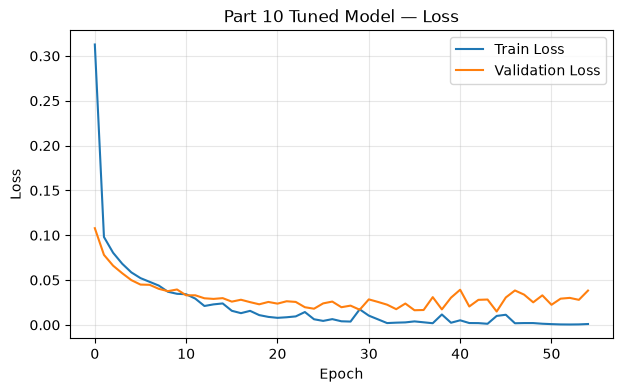

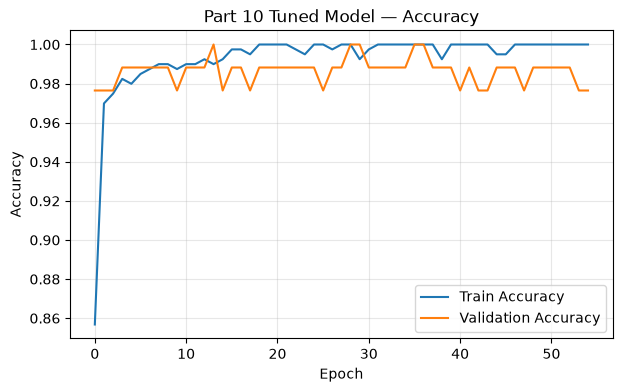

Decision threshold on the validation set


,Threshold,Val Accuracy,Malignant Recall,Benign Recall
0,0.3,1.000000,1.0,1.000000
1,0.4,1.000000,1.0,1.000000
2,0.5,0.988235,1.0,0.981132
3,0.6,0.988235,1.0,0.981132
4,0.7,0.988235,1.0,0.981132


Epochs run: 55
Validation loss: 0.014915759675204754
Validation accuracy: 0.9882352948188782
Test loss: 0.1356235295534134
Test accuracy: 0.9651162624359131

Confusion matrix (rows = actual, columns = predicted):
[[29  3]
 [ 0 54]]

              precision    recall  f1-score   support

   Malignant      1.000     0.906     0.951        32
      Benign      0.947     1.000     0.973        54

    accuracy                          0.965        86
   macro avg      0.974     0.953     0.962        86
weighted avg      0.967     0.965     0.965        86



,Model,Parameters,Val Loss,Test Accuracy
0,"Part 7 final (medium, Dropout, early stopping)",4609,0.022187,0.941860
1,Part 10 tuned,2305,0.014916,0.965116


In [28]:
keras.backend.clear_session()
keras.utils.set_random_seed(TUNING_SEED)

tuned_model = build_tuned_model(best_config)
tuned_model.compile(
    optimizer=build_optimizer(best_config["optimizer"], float(best_config["learning_rate"])),
    loss=loss_function,
    metrics=["accuracy"]
)
tuned_model.summary()

tuned_early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuned_history = tuned_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=int(best_config["batch_size"]),
    callbacks=[tuned_early_stop],
    verbose=1
)

plot_learning_curves(tuned_history, "Part 10 Tuned Model")

tuned_epochs = len(tuned_history.history["loss"])
tuned_val_loss, tuned_val_accuracy = tuned_model.evaluate(X_val, y_val, verbose=0)

threshold_rows = []
validation_probabilities = tuned_model.predict(X_val, verbose=0).ravel()

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    threshold_predictions = (validation_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Val Accuracy": accuracy_score(y_val, threshold_predictions),
        "Malignant Recall": recall_score(y_val, threshold_predictions, pos_label=0),
        "Benign Recall": recall_score(y_val, threshold_predictions, pos_label=1)
    })

threshold_results = pd.DataFrame(threshold_rows)

print("Decision threshold on the validation set")
display(threshold_results)

tuned_test_loss, tuned_test_accuracy = tuned_model.evaluate(X_test, y_test, verbose=0)

tuned_probabilities = tuned_model.predict(X_test, verbose=0)
tuned_predictions = (tuned_probabilities >= 0.5).astype(int).ravel()

print("Epochs run:", tuned_epochs)
print("Validation loss:", tuned_val_loss)
print("Validation accuracy:", tuned_val_accuracy)
print("Test loss:", tuned_test_loss)
print("Test accuracy:", tuned_test_accuracy)

print()
print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(y_test, tuned_predictions))

print()
print(classification_report(y_test, tuned_predictions, target_names=["Malignant", "Benign"], digits=3))

tuning_comparison_rows = []

tuning_comparison_rows.append({
    "Model": f"Part 7 final (medium, {best_regularizer}, early stopping)",
    "Parameters": final_model.count_params(),
    "Val Loss": final_val_loss,
    "Test Accuracy": final_test_accuracy
})

tuning_comparison_rows.append({
    "Model": "Part 10 tuned",
    "Parameters": tuned_model.count_params(),
    "Val Loss": tuned_val_loss,
    "Test Accuracy": tuned_test_accuracy
})

tuning_comparison = pd.DataFrame(tuning_comparison_rows)
tuning_comparison

### Part 10 Analysis

**What the coarse search found.** Forty random configurations produced validation losses from 0.0283 to well above 0.16. The sensitivity table ranks the hyperparameters by how far each one moves the median validation loss across its range, and the ordering is decisive: learning rate 0.130, dropout 0.063, L2 0.053, depth 0.029, optimizer 0.028, width 0.025, batch size 0.015, activation 0.009, BatchNorm 0.007. Learning rate alone accounts for twice the spread of the next hyperparameter and nearly twenty times that of BatchNorm, which is why Part 6 got its largest single improvement from the same setting.

**Why the leaders were re-scored across seeds.** The coarse stage runs one seed per configuration. On an 85-row validation set that is not enough to separate configurations: the coarse leader at 0.0283 fell to nineteenth of twenty-one when re-run across three seeds, and the best candidate on the seed-averaged score, 0.0106, had not been sampled at all in the coarse stage. Selecting on a single run would have picked the wrong model.

**Selected configuration.** One hidden layer of 64 units, ReLU with He initialization, BatchNorm, dropout 0.1, RMSprop at lr = 0.01, batch size 128, early stopping on validation loss with patience 10. Mean validation loss 0.0106 with standard deviation 0.0037 across seeds, mean validation accuracy 1.0000, mean 43 epochs before stopping.

**Confirmation.** Retrained once and evaluated once on the test set: 55 epochs, validation loss 0.0149, validation accuracy 0.9882, test accuracy 0.9651, 2,305 parameters. Against the Part 7 model it is better on validation loss (0.0149 against 0.0222), better on test accuracy (0.9651 against 0.9419) and half the size (2,305 against 4,609). Its learning curve is the only one in the notebook that shows a genuine good fit: training and validation loss fall together and then both stay flat, with validation settling around 0.03 instead of turning upward.

**Error analysis.** The three test errors are all malignant cases predicted benign, and there are no errors in the other direction, so malignant recall is 0.906 while benign recall is 1.000. For a screening task that is the wrong direction to be wrong in. The threshold table shows the validation set cannot resolve this: every threshold from 0.3 to 0.7 gives malignant recall of 1.000 there, so the operating point was left at the default 0.5 rather than tuned on 85 rows. Fixing this properly needs more validation data, not more tuning.

**What the search says about the lab's opening question.** The search covered one to three hidden layers and widths from 16 to 256, and the best configuration it found was the shallowest available. Depth was the fourth most important hyperparameter out of nine, well behind learning rate, and its best value was 1. That is the same conclusion the M1/M2/M3 comparison reached in Part 4, arrived at independently.